# ch214 — Saddle Points

**Part VII: Calculus**

---

## 1. What a Saddle Point Is

A **saddle point** is a stationary point where the gradient is zero, but it is neither a local minimum nor a local maximum. The function curves upward in some directions and downward in others.

Named after the shape of a horse saddle: a flat surface that is a minimum along the horse's spine and a maximum across the saddle.

**In high dimensions**, saddle points are far more common than local minima. For a random function in n dimensions at a stationary point, each of the n principal curvature directions is independently positive or negative with some probability p. The probability that all n are positive (a true minimum) decays exponentially: pⁿ → 0 as n → ∞.

This has profound implications for neural network optimization.

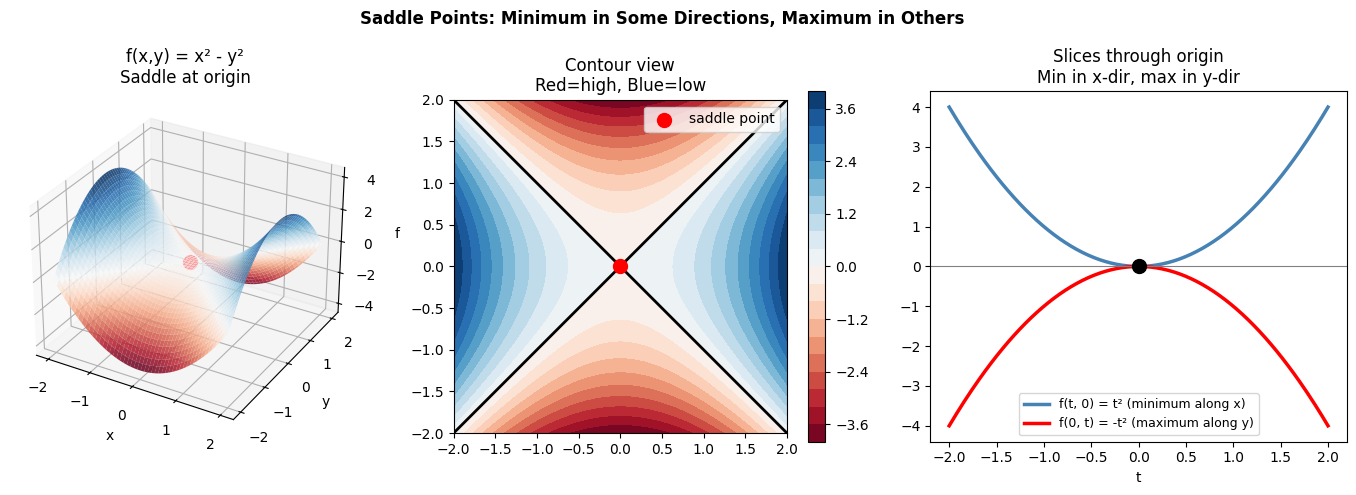

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Classic saddle: f(x,y) = x^2 - y^2
f_saddle = lambda x, y: x**2 - y**2

x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = f_saddle(X, Y)

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='RdBu', alpha=0.85)
ax1.scatter([0], [0], [0], color='red', s=100, zorder=10)
ax1.set_title('f(x,y) = x² - y²\nSaddle at origin')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('f')

ax2 = fig.add_subplot(132)
cs = ax2.contourf(X, Y, Z, levels=20, cmap='RdBu')
ax2.contour(X, Y, Z, levels=[0], colors='black', linewidths=2)
ax2.scatter([0], [0], color='red', s=100, zorder=8, label='saddle point')
ax2.set_title('Contour view\nRed=high, Blue=low')
ax2.set_aspect('equal')
ax2.legend()
plt.colorbar(cs, ax=ax2)

# Slices through saddle
ax3 = fig.add_subplot(133)
t = np.linspace(-2, 2, 200)
ax3.plot(t, t**2,  color='steelblue', linewidth=2.5, label='f(t, 0) = t² (minimum along x)')
ax3.plot(t, -t**2, color='red', linewidth=2.5, label='f(0, t) = -t² (maximum along y)')
ax3.scatter([0], [0], color='black', s=100, zorder=8)
ax3.axhline(0, color='gray', linewidth=0.8)
ax3.set_title('Slices through origin\nMin in x-dir, max in y-dir')
ax3.set_xlabel('t')
ax3.legend(fontsize=9)

plt.suptitle('Saddle Points: Minimum in Some Directions, Maximum in Others', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Gradient at origin (the saddle point):
  ∇f(0, 0) = [0 0]

Gradient away from origin:
  ∇f(0.10, 0.00) = [ 0.2 -0. ]  (magnitude=0.2000)
  ∇f(0.00, 0.10) = [ 0.  -0.2]  (magnitude=0.2000)
  ∇f(0.05, 0.05) = [ 0.1 -0.1]  (magnitude=0.1414)

Near the saddle, the gradient is tiny — GD is very slow.
This is why saddle points can severely slow training.


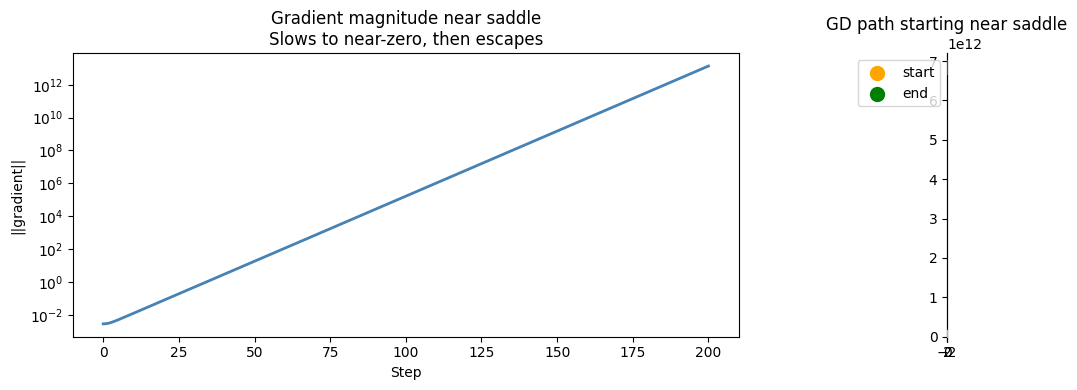

In [2]:
# Gradient at the saddle point is zero — gradient descent stalls there
grad_saddle = lambda x, y: np.array([2*x, -2*y])

print('Gradient at origin (the saddle point):')
print(f'  ∇f(0, 0) = {grad_saddle(0, 0)}')
print()
print('Gradient away from origin:')
for x0, y0 in [(0.1, 0.0), (0.0, 0.1), (0.05, 0.05)]:
    g = grad_saddle(x0, y0)
    print(f'  ∇f({x0:.2f}, {y0:.2f}) = {g}  (magnitude={np.linalg.norm(g):.4f})')

print()
print('Near the saddle, the gradient is tiny — GD is very slow.')
print('This is why saddle points can severely slow training.')

# Simulate GD near saddle (starts just slightly off-center)
w = np.array([0.001, 0.001])  # tiny perturbation
lr = 0.1
path = [w.copy()]
for _ in range(200):
    g = grad_saddle(*w)
    w = w - lr * g
    path.append(w.copy())
path = np.array(path)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogy(np.linalg.norm(np.array([grad_saddle(*p) for p in path]), axis=1) + 1e-15, color='steelblue', linewidth=2)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('||gradient||')
axes[0].set_title('Gradient magnitude near saddle\nSlows to near-zero, then escapes')

axes[1].plot(path[:, 0], path[:, 1], '-', color='steelblue', linewidth=2)
axes[1].scatter(*path[0], color='orange', s=100, zorder=8, label='start')
axes[1].scatter(*path[-1], color='green', s=100, zorder=8, label='end')
cs = axes[1].contourf(X, Y, Z, levels=15, cmap='RdBu', alpha=0.5)
axes[1].set_title('GD path starting near saddle')
axes[1].legend(); axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()


## 2. Identifying Saddle Points via the Hessian

At a stationary point where ∇f = 0, the **Hessian matrix** H (the matrix of second partial derivatives) tells us the type:

- All eigenvalues of H > 0: **local minimum**
- All eigenvalues of H < 0: **local maximum**  
- Mixed eigenvalues: **saddle point**

*(The Hessian is formalized in ch217 — Second Derivatives.)*

In [3]:
# For f(x,y) = x^2 - y^2:
# H = [[d^2f/dx^2, d^2f/dxdy], [d^2f/dydx, d^2f/dy^2]]
#   = [[2, 0], [0, -2]]

H = np.array([[2.0, 0.0],
              [0.0, -2.0]])
eigenvalues, eigenvectors = np.linalg.eig(H)

print('Hessian at origin for f(x,y) = x² - y²:')
print(f'  H = {H}')
print(f'  Eigenvalues: {eigenvalues}')
print(f'  → Mixed sign eigenvalues → SADDLE POINT')
print()

# For f(x,y) = x^2 + y^2 (minimum):
H_min = np.array([[2.0, 0.0], [0.0, 2.0]])
ev_min = np.linalg.eigvals(H_min)
print(f'Hessian for f(x,y) = x² + y²:')
print(f'  Eigenvalues: {ev_min}  → all positive → LOCAL MINIMUM')
print()

# For f(x,y) = -x^2 - y^2 (maximum):
H_max = np.array([[-2.0, 0.0], [0.0, -2.0]])
ev_max = np.linalg.eigvals(H_max)
print(f'Hessian for f(x,y) = -x² - y²:')
print(f'  Eigenvalues: {ev_max}  → all negative → LOCAL MAXIMUM')


Hessian at origin for f(x,y) = x² - y²:
  H = [[ 2.  0.]
 [ 0. -2.]]
  Eigenvalues: [ 2. -2.]
  → Mixed sign eigenvalues → SADDLE POINT

Hessian for f(x,y) = x² + y²:
  Eigenvalues: [2. 2.]  → all positive → LOCAL MINIMUM

Hessian for f(x,y) = -x² - y²:
  Eigenvalues: [-2. -2.]  → all negative → LOCAL MAXIMUM


## 3. Escaping Saddle Points

Gradient descent with noise (SGD) naturally perturbs the trajectory, helping escape saddle points. Dedicated methods include:
- Adding Gaussian noise to gradients
- Momentum-based methods (accumulate gradient history)
- Second-order methods (use Hessian curvature directly)

---

## 4. Summary

- Saddle points: ∇f = 0 but not a minimum or maximum
- Identified by the Hessian: mixed-sign eigenvalues → saddle
- Gradient is zero at saddle → gradient descent stalls
- In high dimensions, saddle points are common — more common than local minima
- SGD noise and momentum help escape saddle points

---

## 5. Forward References

The Hessian matrix — used to classify critical points — is the subject of ch217 — Second Derivatives. Momentum-based methods that escape saddle points more efficiently are discussed in ch291 — Optimization Methods (Part IX). The probability of being near a saddle vs a minimum in high-dimensional random functions connects to random matrix theory, relevant in Part VIII — Probability.